In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt

data_root = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual/")
fig_dir = data_root / "_figures" / "train_test"
fig_dir.mkdir(exist_ok=True, parents=True)


subs_dir = Path("/nas/cee-water/cjgleason/ted/graph_delineator/data/clamped_manual_matchups_500/subbasins/USGS-07374000_subbasins.parquet")
subbasins = gpd.read_parquet(subs_dir).set_index('id')

subbasins

,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown
id,,,,,,
74028485,"MULTIPOLYGON (((-94.79458 42.81625, -94.79375 ...",173.772278,1.737723e+02,original,False,74023879
74021683,"POLYGON ((-103.31875 44.19458, -103.31708 44.1...",31.952856,3.195286e+01,original,False,74017731
74043667,"POLYGON ((-100.30542 39.51208, -100.30292 39.5...",70.224778,7.022478e+01,original,False,74039036
74043525,"POLYGON ((-100.50875 39.46375, -100.50792 39.4...",225.434216,2.254342e+02,original,False,74039036
74043323,"POLYGON ((-101.07125 39.45125, -101.06792 39.4...",169.761879,1.697619e+02,original,False,74039673
...,...,...,...,...,...,...
USGS-07292500,"POLYGON ((-91.13375 31.24708, -91.13371 31.247...",483.330429,2.039318e+03,gauge,True,74070126
USGS-07290650,"POLYGON ((-90.89542 32.03625, -90.89542 32.036...",463.665634,1.697335e+03,gauge,True,74069837
USGS-07291000,"POLYGON ((-90.84875 31.58125, -90.84875 31.581...",467.570773,4.675708e+02,gauge,True,74070222


In [2]:
gauges = pd.read_parquet('/nas/cee-ice/data/gg_parquet/usgs/site_metadata/data.parquet').set_index('site_id')
subbasins = subbasins.join(gauges)

In [3]:
train_subs = pd.read_csv('/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual/basin_lists/train_ms_8020.csv')
test_subs = pd.read_csv('/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual/basin_lists/test_ms_8020.csv')

In [4]:
subbasins['subset'] = ''
subbasins.loc[train_subs['subbasin'].values, 'subset'] = 'train'
subbasins.loc[test_subs['subbasin'].values, 'subset'] = 'test'

subbasins['subset']

id
74028485              
74021683              
74043667              
74043525              
74043323              
                 ...  
USGS-07292500    train
USGS-07290650    train
USGS-07291000    train
USGS-07295000     test
USGS-07374000    train
Name: subset, Length: 8143, dtype: object

In [96]:
# 1. Simplify geometry to centroids
# Using a copy to preserve original geometry for background plotting if needed
centroids = subbasins.copy()
centroids['geometry'] = subbasins.geometry.centroid

# 2. Align source and target coordinates
# We merge the dataframe with itself to link the current node (source) 
# with the downstream node (target) using the 'nextdown' column.
edges = centroids.merge(
    centroids[['geometry']], 
    left_on='nextdown', 
    right_index=True, 
    how='inner', 
    suffixes=('_start', '_end')
)

# 3. Calculate arrow vectors (u, v)
# u = x_end - x_start
# v = y_end - y_start
edges['u'] = edges['geometry_end'].x - edges['geometry_start'].x
edges['v'] = edges['geometry_end'].y - edges['geometry_start'].y

/tmp/ipykernel_1189021/2598068974.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids['geometry'] = subbasins.geometry.centroid


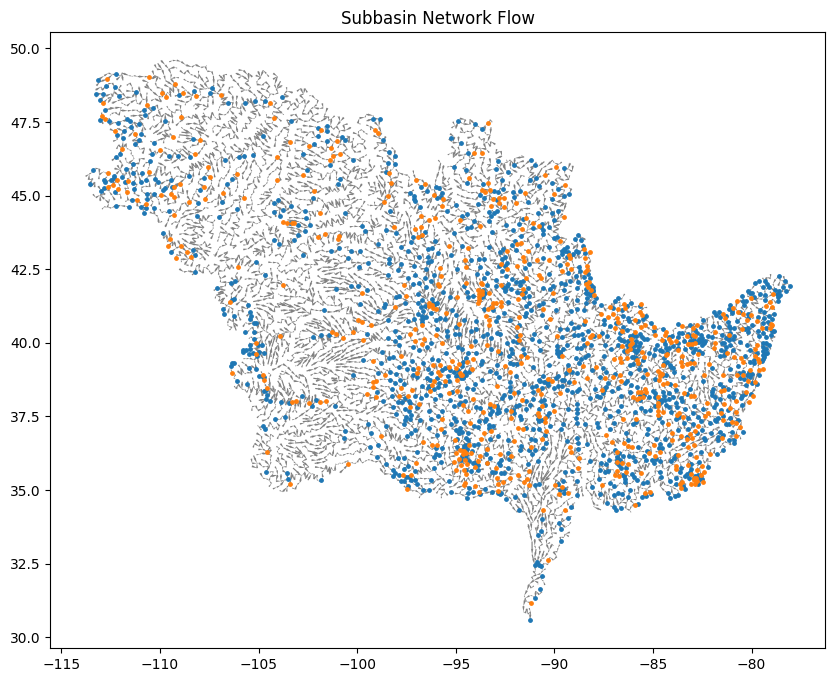

In [97]:
# 4. Plot
fig, ax = plt.subplots(figsize=(10, 8))


train_c = centroids[centroids['subset']=='train']
ax.scatter(train_c.geometry.x, train_c.geometry.y, c='tab:blue', s=6, zorder=3, label='Train')

test_c = centroids[centroids['subset']=='test']
ax.scatter(test_c.geometry.x, test_c.geometry.y, c='tab:orange', s=6, zorder=3, label='Test')

# Plot edges (arrows)
# angles='xy', scale_units='xy', scale=1 ensures arrows are drawn 
# in data coordinates (1 unit length = 1 degree) rather than plot inches.
ax.quiver(
    edges['geometry_start'].x, 
    edges['geometry_start'].y, 
    edges['u'], 
    edges['v'],
    angles='xy', 
    scale_units='xy', 
    scale=1, 
    color='grey', 
    width=0.0015, 
    headwidth=2,
    zorder=0
)

# plt.legend()
ax.set_title("Subbasin Network Flow")
plt.show()

fig.savefig(fig_dir / 'MS_network.png', transparent=True, dpi=300)

In [98]:
print(f"{len(train_c) = }")
print(f"{len(test_c) = }")

len(train_c) = 1390
len(test_c) = 597


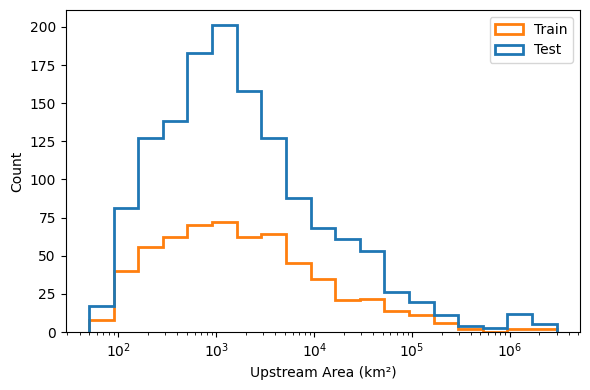

In [104]:
areas = [train_c['uparea_km2'].values, test_c['uparea_km2'].values]
bins = np.logspace(np.log10(50), np.log10(3000000), 20)

plt.close('all')
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(areas, bins=bins, histtype='step', linewidth=2)
ax.set_xscale('log')
ax.set_ylabel("Count")
ax.set_xlabel("Upstream Area (km²)")
ax.legend(['Train','Test'])

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / 'area_hists.png', transparent=True, dpi=300)

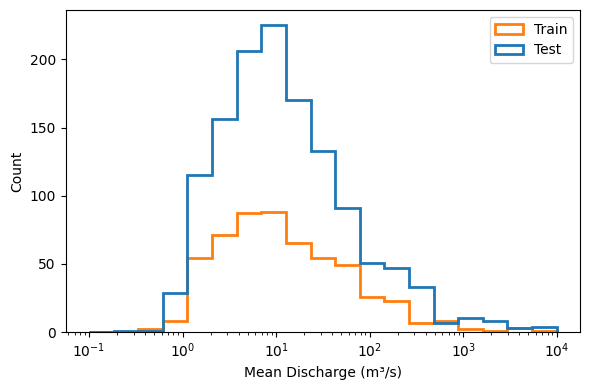

In [105]:
areas = [train_c['mean_discharge'].values, test_c['mean_discharge'].values]
bins = np.logspace(np.log10(0.1), np.log10(10000), 20)

plt.close('all')
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(areas, bins=bins, histtype='step', linewidth=2)
ax.set_xscale('log')
ax.set_ylabel("Count")
ax.set_xlabel("Mean Discharge (m³/s)")
ax.legend(['Train','Test'])

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / 'Q_hists.png', transparent=True, dpi=300)